# Benchmark: Slide-seq Brain Atlas (top NMF genes across all factors)

Same setup as `B.1.benchmark_posPC2.ipynb` but gene selection is **NMF-based** instead of PCA-based.
No PCA is computed.

**Gene selection:**
- Run NMF (k=15) on the bottom half of Puck 06 (log-normalised, HVG-filtered, unit-variance scaled).
- For each NMF factor take the **top 10 highest-loading genes** from the H matrix.
- Pool unique genes across all factors → perturb set.

**Perturbation:** same Poisson scheme as B.1 applied inside the central circle.

In [159]:
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
from sklearn.decomposition import NMF
from pathlib import Path

RAND_SEED = 28
TOP_GENES_PER_FACTOR = 1
N_FACTORS = 15

#  Optional: spatial sparsity 
# Set PERTURB_FRAC < 1.0 to perturb only a random fraction of circle beads.
# This makes the benchmark harder: the boundary becomes fuzzy and NMF must
# distinguish signal from noise within the circle rather than detecting a
# hard edge. `in_circle` remains the ground truth for the full circle.
# Set to 1.0 to perturb all circle beads (original behaviour).
PERTURB_FRAC = 1.0
PERTURB_FRAC = 0.5

# Fixed lambda: add counts regardless of baseline expression.
# Mean-based lambda explodes for highly-expressed NMF genes.
FIXED_LAM = 0.15


DATA_DIR = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/All_Pucks_h5ad')

In [160]:
# Check how many pucks we have
puck_files = list(DATA_DIR.glob('*.h5ad'))
print(f'Found {len(puck_files)} puck files.')
PUCK_IDS = [f'{i:02d}' for i in range(1, 10)]   # 01 – 09

Found 111 puck files.


In [161]:
def load_puck_obs(puck_id):
    """Load a single puck keeping only obs (skips the large X matrix)."""
    path = DATA_DIR / f'Puck_Num_{puck_id}.h5ad'
    tmp = ad.read_h5ad(path, backed='r')
    obs = tmp.obs.copy()
    obs['puck_id'] = puck_id
    tmp.file.close()
    return obs

pucks = {pid: load_puck_obs(pid) for pid in PUCK_IDS}
print(f'Loaded {len(pucks)} pucks')
for pid, obs in pucks.items():
    print(f'  Puck {pid}: {len(obs):>7,} beads  |  TopStruct: {obs["TopStruct"].value_counts().to_dict()}')

Loaded 9 pucks
  Puck 01: 129,722 beads  |  TopStruct: {'NA': 68223, 'OLF': 31596, 'Isocortex': 23681, 'FB_VS_grey': 6222}
  Puck 02: 114,834 beads  |  TopStruct: {'NA': 58366, 'OLF': 28419, 'Isocortex': 23027, 'FB_VS_grey': 5022}
  Puck 03: 117,761 beads  |  TopStruct: {'NA': 54065, 'Isocortex': 35338, 'OLF': 25102, 'FB_VS_grey': 3256}
  Puck 04: 122,129 beads  |  TopStruct: {'Isocortex': 44983, 'NA': 44609, 'OLF': 29324, 'FB_VS_grey': 3213}
  Puck 05: 110,160 beads  |  TopStruct: {'NA': 42864, 'Isocortex': 39243, 'OLF': 25682, 'FB_VS_grey': 2371}
  Puck 06: 100,322 beads  |  TopStruct: {'Isocortex': 55999, 'OLF': 22060, 'NA': 20474, 'FB_VS_grey': 1789}
  Puck 07: 127,757 beads  |  TopStruct: {'Isocortex': 57203, 'NA': 41849, 'OLF': 26376, 'FB_VS_grey': 2329}
  Puck 08: 104,778 beads  |  TopStruct: {'Isocortex': 52670, 'NA': 28024, 'OLF': 22237, 'FB_VS_grey': 1847}
  Puck 09: 124,788 beads  |  TopStruct: {'NA': 56147, 'Isocortex': 47309, 'OLF': 19745, 'FB_VS_grey': 1587}


## Spatial maps

In [162]:
def plot_puck(adata, title='', color='TopStruct', point_size=0.8):
    obs = adata.obs
    cats = sorted(obs[color].astype(str).unique(), key=lambda x: (x == 'NA', x))
    cmap = plt.colormaps['tab20'].resampled(len(cats))
    col_dict = {c: cmap(i) for i, c in enumerate(cats)}
    col_dict['NA'] = (0.82, 0.82, 0.82, 1.0)

    x = obs['Raw_Slideseq_X'].values.astype(float)
    y = obs['Raw_Slideseq_Y'].values.astype(float)
    c = [col_dict[str(v)] for v in obs[color]]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, c=c, s=point_size, linewidths=0, edgecolors='none', rasterized=True)
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_title(f'{title}  ({color}, n={len(obs):,})', fontsize=10)
    patches = [mpatches.Patch(color=col_dict[c], label=c) for c in cats]
    ax.legend(handles=patches, fontsize=7, loc='lower right', frameon=False, markerscale=4)
    plt.tight_layout()
    plt.show()

01


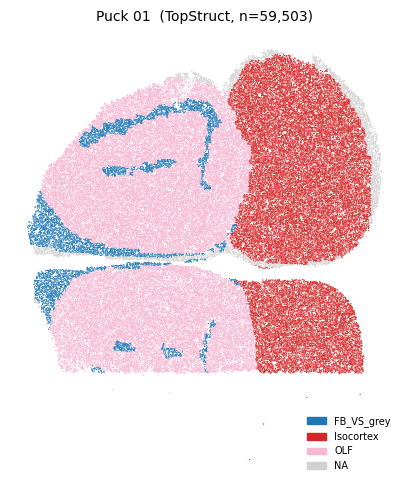

02


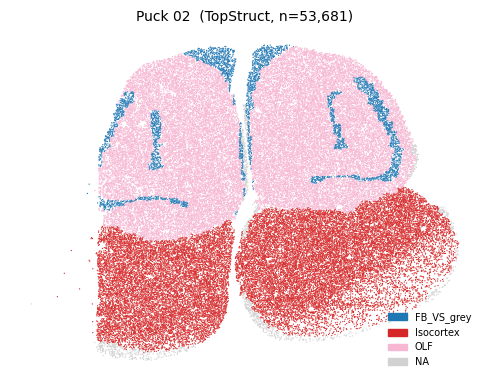

In [163]:
for pid in PUCK_IDS[:2]:
    print(pid)
    obs = pucks[pid]
    obs = obs[obs['IsOutsideCCF'] == 0]
    tmp = ad.AnnData(obs=obs)
    plot_puck(tmp, title=f'Puck {pid}')

In [164]:
# Load full adata for puck 06 (including expression matrix), filter to tissue beads
adata06 = ad.read_h5ad(DATA_DIR / 'Puck_Num_06.h5ad')
adata06 = adata06[adata06.obs['IsOutsideCCF'] == 0].copy()
print(adata06)

AnnData object with n_obs × n_vars = 79800 × 26548
    obs: 'nCount_Spatial', 'nFeature_Spatial', 'PuckID', 'Raw_Slideseq_X', 'Raw_Slideseq_Y', 'Puck_Depth', 'nCount_Spatial.1', 'nFeature_Spatial.1', 'CCF_X', 'CCF_Y', 'CCF_Z', 'TopStruct', 'DeepCCF', 'CCF_acronym', 'CCF_ID', 'CCF_Name', 'CCF_LeftRight', 'IsOutsideCCF', 'Correponding_DissectateSegName', 'Correponding_DissectateSegID', 'NisslTiffX', 'NisslTiffY', 'BeadBarcode', '.id', 'orig.ident'
    var: '_index', 'features'


387.0 4259.6
Natural split point in Y for puck 06: 2323.3


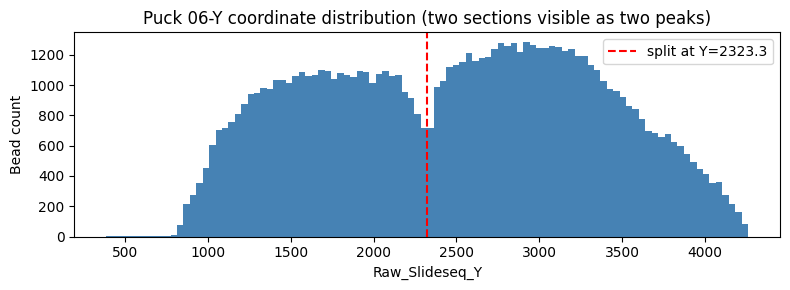

In [165]:
# Find the natural split point in puck 06 by looking at the Y-axis bead density
y_all = adata06.obs['Raw_Slideseq_Y'].values.astype(float)

print(min(y_all), max(y_all))
split_point = min(y_all) + (max(y_all) - min(y_all)) / 2
print(f'Natural split point in Y for puck 06: {split_point:.1f}')
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(y_all, bins=100, color='steelblue', edgecolor='none')
ax.axvline(split_point, color='red', linestyle='--', label=f'split at Y={split_point:.1f}')
ax.set_xlabel('Raw_Slideseq_Y')
ax.set_ylabel('Bead count')
ax.set_title('Puck 06-Y coordinate distribution (two sections visible as two peaks)')
ax.legend()
plt.tight_layout()
plt.show()

Top half:    34,392 beads
Bottom half: 45,408 beads


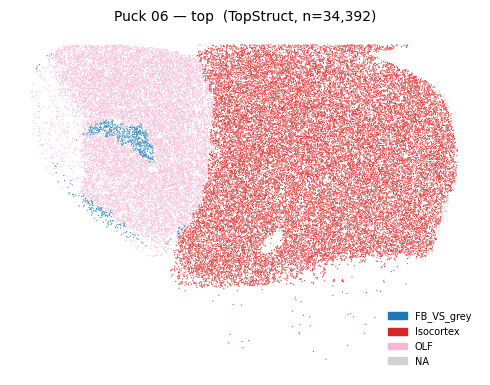

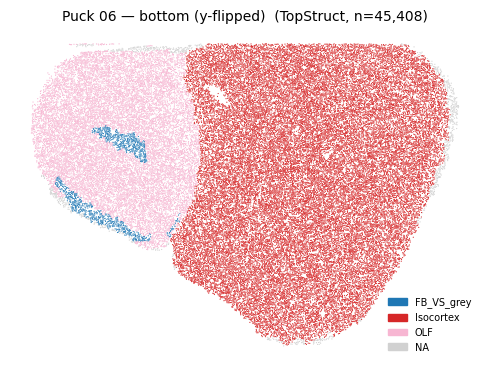

In [166]:
y = adata06.obs['Raw_Slideseq_Y'].values.astype(float)
split_y = split_point

adata06_top = adata06[y <= split_y].copy()
adata06_bot = adata06[y >  split_y].copy()

print(f'Top half:    {adata06_top.n_obs:,} beads')
print(f'Bottom half: {adata06_bot.n_obs:,} beads')

FLIP_Y = True
y_bot = adata06_bot.obs['Raw_Slideseq_Y'].values.astype(float)
if FLIP_Y:
    adata06_bot.obs['Raw_Slideseq_Y'] = y_bot.max() + y_bot.min() - y_bot

plot_puck(adata06_top, 'Puck 06 — top', point_size=0.7)
plot_puck(adata06_bot, 'Puck 06 — bottom (y-flipped)', point_size=0.7)

Puck center:   (3332, 3292)
Puck radius:   913
Circle radius: 408  (targets 1/5 of puck area)
Beads selected: 6,394 / 45,408  (14.1%)


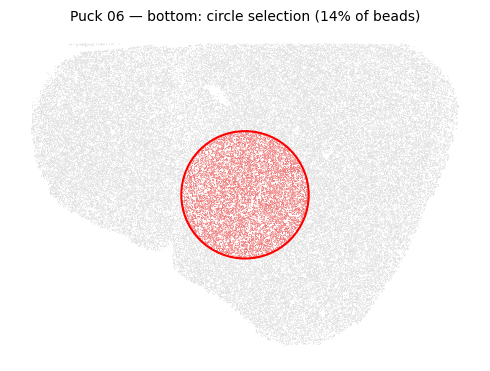

In [167]:
# Define a circular region covering ~1/5 of the puck area
x = adata06_bot.obs['Raw_Slideseq_X'].values.astype(float)
y = adata06_bot.obs['Raw_Slideseq_Y'].values.astype(float)

cx = (x.min() + x.max()) / 2
cy = (y.min() + y.max()) / 2
puck_radius   = max(x.max() - x.min(), y.max() - y.min()) / 3
circle_radius = puck_radius / np.sqrt(5)

print(f'Puck center:   ({cx:.0f}, {cy:.0f})')
print(f'Puck radius:   {puck_radius:.0f}')
print(f'Circle radius: {circle_radius:.0f}  (targets 1/5 of puck area)')

dist      = np.sqrt((x - cx)**2 + (y - cy)**2)
in_circle = dist <= circle_radius
adata06_bot.obs['in_circle'] = in_circle
print(f'Beads selected: {in_circle.sum():,} / {len(in_circle):,}  ({in_circle.mean():.1%})')

fig, ax = plt.subplots(figsize=(5, 5))
colors = np.where(in_circle, '#e84545', '#d3d3d3')
ax.scatter(x, y, c=colors, s=0.5, linewidths=0, edgecolors='none', rasterized=True)
ax.add_patch(plt.Circle((cx, cy), circle_radius, fill=False, edgecolor='red', linewidth=1.5))
ax.set_aspect('equal', 'box')
ax.axis('off')
ax.set_title(f'Puck 06 — bottom: circle selection ({in_circle.mean():.0%} of beads)', fontsize=10)
plt.tight_layout()
plt.show()

## NMF-based gene selection

Run NMF on the (unperturbed) bottom-half data.  
For each factor take the top `TOP_GENES_PER_FACTOR` genes by H loading.  
Pool unique genes across all factors — these are the perturbation targets.

In [168]:
# Preprocess a copy for NMF (do NOT modify adata06_bot — we need raw counts for perturbation)
adata_nmf = adata06_bot.copy()

# HVG selection: compute on a temporary lognorm copy, then apply mask to raw counts
# (seurat_v3 requires skmisc which is not installed; seurat/cell_ranger expect lognorm)
_tmp = adata_nmf.copy()
sc.pp.normalize_total(_tmp, target_sum=1e4)
sc.pp.log1p(_tmp)
sc.pp.highly_variable_genes(_tmp, n_top_genes=2000, flavor='seurat', subset=False)
adata_nmf.var['highly_variable'] = _tmp.var['highly_variable']
del _tmp

adata_nmf = adata_nmf[:, adata_nmf.var['highly_variable']].copy()
print(f'HVGs: {adata_nmf.var["highly_variable"].sum()}')
print(f'NMF input shape: {adata_nmf.shape}')

# Unit-variance scaling without centering — preserves non-negativity for NMF
# adata_nmf.X is still raw counts at this point
sc.pp.scale(adata_nmf, zero_center=False)

HVGs: 2000
NMF input shape: (45408, 2000)


In [169]:
X_nmf_input = adata_nmf.X
if sp.issparse(X_nmf_input):
    X_nmf_input = X_nmf_input.toarray()
X_nmf_input = X_nmf_input.astype(np.float32)

nmf_model = NMF(
    n_components=N_FACTORS,
    init='nndsvda',
    random_state=RAND_SEED,
    max_iter=1000,
    solver='cd',
)
W = nmf_model.fit_transform(X_nmf_input)
H = nmf_model.components_   # shape: (N_FACTORS, n_genes)

print(f'W shape: {W.shape},  H shape: {H.shape}')
print(f'Reconstruction error: {nmf_model.reconstruction_err_:.2f}')

W shape: (45408, 15),  H shape: (15, 2000)
Reconstruction error: 9368.02


In [170]:
print('Top genes per factor:', TOP_GENES_PER_FACTOR)

Top genes per factor: 1


In [171]:
gene_names = (
    adata_nmf.var['features'].values
    if 'features' in adata_nmf.var.columns
    else adata_nmf.var_names.values
)

n_top = int(TOP_GENES_PER_FACTOR)   # guard against float values

nmf_gene_records = []
seen = set()
nmf_genes_ordered = []   # unique, ordered by first appearance

for fi in range(N_FACTORS):
    top_idx   = np.argsort(H[fi])[::-1][:n_top]
    top_genes = gene_names[top_idx]
    print(f'F{fi+1:>2}: {list(top_genes)}')
    for rank, (gi, g) in enumerate(zip(top_idx, top_genes)):
        nmf_gene_records.append({
            'gene':    g,
            'factor':  fi + 1,
            'rank':    rank + 1,
            'loading': float(H[fi, gi]),
        })
        if g not in seen:
            nmf_genes_ordered.append(g)
            seen.add(g)

nmf_genes_df = pd.DataFrame(nmf_gene_records)
print(f'\nTotal unique NMF genes for perturbation: {len(nmf_genes_ordered)}')

F 1: ['Ywhab']
F 2: ['Hsf5']
F 3: ['Plp1']
F 4: ['Pla2g7']
F 5: ['Chmp1b']
F 6: ['Haus7']
F 7: ['Phactr1']
F 8: ['Pyurf']
F 9: ['Gm36831']
F10: ['9630013A20Rik']
F11: ['Traf3ip2']
F12: ['Sycp3']
F13: ['Gm26850']
F14: ['Gm37954']
F15: ['Ctss']

Total unique NMF genes for perturbation: 15


In [172]:
OUT_DIR = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler/benchmark/generated_benchmark_data')
OUT_DIR.mkdir(exist_ok=True)
nmf_genes_df.to_csv(OUT_DIR / f'nmf_genes_top{int(TOP_GENES_PER_FACTOR * 100)}_per_factor.csv', index=False)
print(f'Saved nmf_genes_top{int(TOP_GENES_PER_FACTOR * 100)}_per_factor.csv ({len(nmf_genes_df)} rows, {len(nmf_genes_ordered)} unique genes)')
print(nmf_genes_df.head(20).to_string())

Saved nmf_genes_top100_per_factor.csv (15 rows, 15 unique genes)
             gene  factor  rank    loading
0           Ywhab       1     1   6.809714
1            Hsf5       2     1  10.160870
2            Plp1       3     1   7.812053
3          Pla2g7       4     1   5.258447
4          Chmp1b       5     1   6.734481
5           Haus7       6     1   9.054196
6         Phactr1       7     1   5.947806
7           Pyurf       8     1   8.247127
8         Gm36831       9     1  12.979431
9   9630013A20Rik      10     1   8.012882
10       Traf3ip2      11     1   8.127912
11          Sycp3      12     1   9.884479
12        Gm26850      13     1   8.304715
13        Gm37954      14     1   7.729190
14           Ctss      15     1   6.753953


## Visualise NMF factor scores on the puck

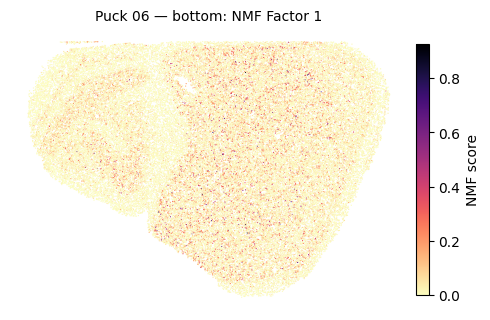

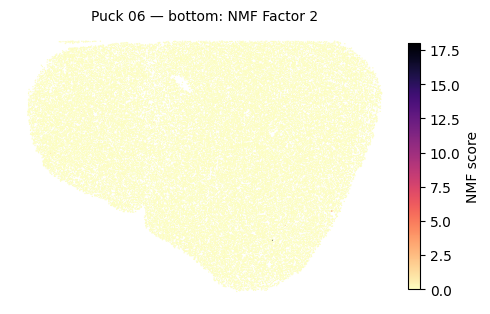

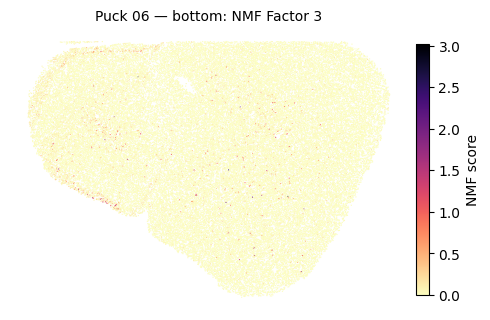

In [173]:
x_bot = adata06_bot.obs['Raw_Slideseq_X'].values.astype(float)
y_bot_coord = adata06_bot.obs['Raw_Slideseq_Y'].values.astype(float)

for fi in range(3):
    scores = W[:, fi]
    fig, ax = plt.subplots(figsize=(5, 5))
    sc_ = ax.scatter(x_bot, y_bot_coord, c=scores, s=0.8, cmap='magma_r',
                     linewidths=0, edgecolors='none', rasterized=True)
    plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.02, label='NMF score')
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_title(f'Puck 06 — bottom: NMF Factor {fi+1}', fontsize=10)
    plt.tight_layout()
    plt.show()

## Perturb circle beads

Same Poisson scheme as B.1: add Poisson(λ) counts where λ = max(mean × 5, 1).

In [174]:
adata06_case = adata06_bot.copy()

all_circle_idx = np.where(adata06_case.obs['in_circle'].values)[0]


print(f'Perturbation fraction: {PERTURB_FRAC:.0%} of circle beads')

if PERTURB_FRAC < 1.0:
    rng_frac   = np.random.default_rng(RAND_SEED + 1)
    circle_idx = rng_frac.choice(all_circle_idx,
                                  size=int(len(all_circle_idx) * PERTURB_FRAC),
                                  replace=False)
    circle_idx = np.sort(circle_idx)
else:
    circle_idx = all_circle_idx

print(f'Circle beads (ground truth): {len(all_circle_idx):,}')
print(f'Circle beads actually perturbed: {len(circle_idx):,}  ({PERTURB_FRAC:.0%})')
# ─────────────────────────────────────────────────────────────────────────

feat_to_col = {g: i for i, g in enumerate(adata06_case.var['features'])}

# Keep only genes present in the expression matrix
nmf_genes_present = [g for g in nmf_genes_ordered if g in feat_to_col]
gene_cols          = np.array([feat_to_col[g] for g in nmf_genes_present])

print(f'NMF genes requested:   {len(nmf_genes_ordered)}')
print(f'NMF genes in matrix:   {len(nmf_genes_present)}')
print(f'Perturbing {len(circle_idx):,} beads × {len(gene_cols)} genes')

X_sub = adata06_case.X[np.ix_(circle_idx, gene_cols)]
if sp.issparse(X_sub):
    X_sub = X_sub.toarray()
X_sub = X_sub.astype(np.float32)


rng       = np.random.default_rng(RAND_SEED)
additions = rng.poisson(FIXED_LAM, size=X_sub.shape).astype(np.float32)

print(f'Fixed lam: {FIXED_LAM}')
print(f'Mean counts added per (bead, gene): {additions.mean():.2f}')
print(f'Total counts added: {additions.sum():,.0f}')

row_idx = np.repeat(circle_idx, len(gene_cols))
col_idx = np.tile(gene_cols,    len(circle_idx))

delta = sp.csr_matrix(
    (additions.flatten(), (row_idx, col_idx)),
    shape=adata06_case.X.shape, dtype=np.float32
)
adata06_case.X = (adata06_case.X + delta).tocsr()

# Sanity check
def col_mean(X, rows, col):
    sub = X[rows, :][:, [col]]
    return (sub.toarray() if sp.issparse(sub) else np.asarray(sub)).mean()

print('\nSanity check (first 5 genes):')
for g in nmf_genes_present[:5]:
    col = feat_to_col[g]
    print(f'  {g:15s}  ctrl={col_mean(adata06_bot.X,  circle_idx, col):.2f}'
          f'  case={col_mean(adata06_case.X, circle_idx, col):.2f}')

Perturbation fraction: 50% of circle beads
Circle beads (ground truth): 6,394
Circle beads actually perturbed: 3,197  (50%)
NMF genes requested:   15
NMF genes in matrix:   15
Perturbing 3,197 beads × 15 genes
Fixed lam: 0.15
Mean counts added per (bead, gene): 0.15
Total counts added: 7,178

Sanity check (first 5 genes):
  Ywhab            ctrl=0.25  case=0.40
  Hsf5             ctrl=0.00  case=0.16
  Plp1             ctrl=0.26  case=0.40
  Pla2g7           ctrl=0.04  case=0.19
  Chmp1b           ctrl=0.01  case=0.15


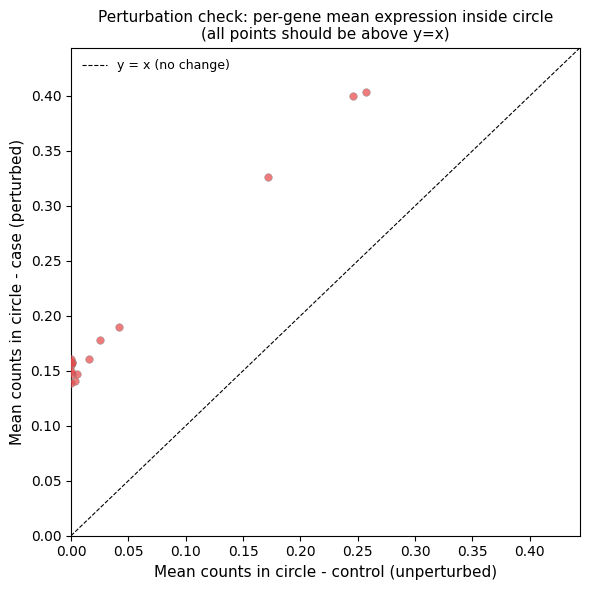

Genes with case > ctrl: 15 / 15
Median fold-change inside circle: 19.86x


In [175]:
# Scatter: ctrl vs case mean expression per gene inside the circle
ctrl_means, case_means, gene_labels = [], [], []
for g in nmf_genes_present:
    col = feat_to_col[g]
    ctrl_means.append(col_mean(adata06_bot.X,  circle_idx, col))
    case_means.append(col_mean(adata06_case.X, circle_idx, col))
    gene_labels.append(g)

ctrl_means = np.array(ctrl_means)
case_means = np.array(case_means)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ctrl_means, case_means, s=30, alpha=0.7, linewidths=0.4,
           edgecolors='grey', color='#e84545', zorder=3)
lim = max(ctrl_means.max(), case_means.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y = x (no change)')
ax.set_xlabel('Mean counts in circle - control (unperturbed)', fontsize=11)
ax.set_ylabel('Mean counts in circle - case (perturbed)',      fontsize=11)
ax.set_title('Perturbation check: per-gene mean expression inside circle\n'
             '(all points should be above y=x)', fontsize=11)
ax.legend(fontsize=9, frameon=False)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

fold_changes = case_means / np.where(ctrl_means > 0, ctrl_means, np.nan)
print(f'Genes with case > ctrl: {(case_means > ctrl_means).sum()} / {len(case_means)}')
print(f'Median fold-change inside circle: {np.nanmedian(fold_changes):.2f}x')

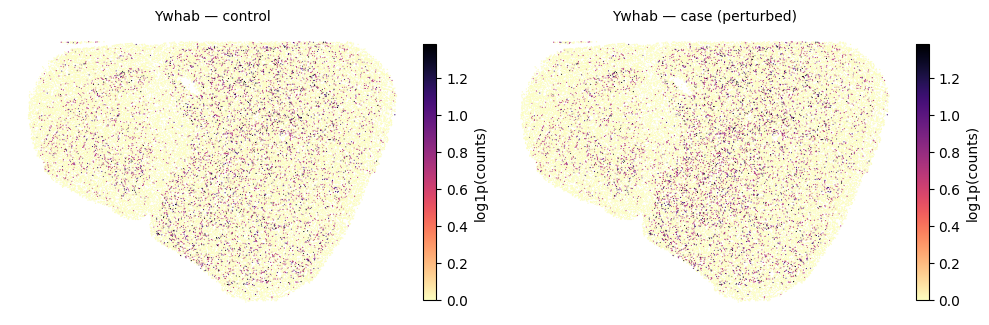

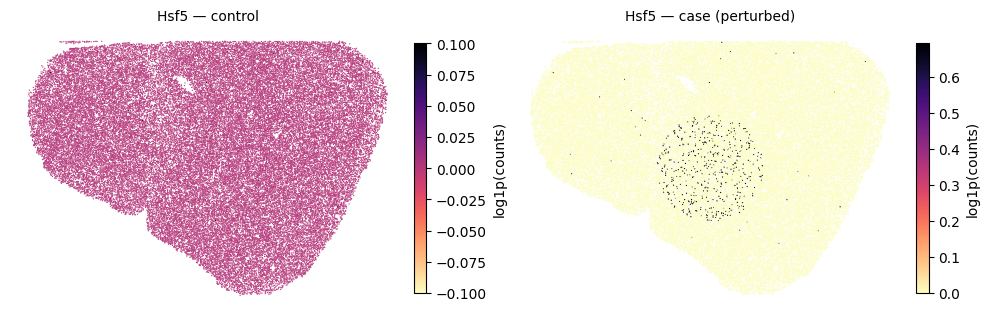

In [176]:
# Spatial expression: ctrl vs case for first two perturbed genes
genes_to_plot = nmf_genes_present[:2]

for gene in genes_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

    for ax, adata, label in zip(axes,
                                 [adata06_bot, adata06_case],
                                 ['control', 'case (perturbed)']):
        feat_to_idx = dict(zip(adata.var['features'], adata.var_names))
        if gene not in feat_to_idx:
            ax.axis('off'); ax.set_title(f'{gene} not found'); continue
        expr = adata[:, feat_to_idx[gene]].X
        if hasattr(expr, 'toarray'):
            expr = expr.toarray().flatten()
        else:
            expr = np.asarray(expr).flatten()
        expr = np.log1p(expr)

        x_c = adata.obs['Raw_Slideseq_X'].values.astype(float)
        y_c = adata.obs['Raw_Slideseq_Y'].values.astype(float)
        vmax = np.percentile(expr, 99)

        sc_ = ax.scatter(x_c, y_c, c=expr, s=0.8, cmap='magma_r',
                         vmin=0, vmax=vmax,
                         linewidths=0, edgecolors='none', rasterized=True)
        plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.02, label='log1p(counts)')
        ax.set_aspect('equal', 'box'); ax.axis('off')
        ax.set_title(f'{gene} — {label}', fontsize=10)

    plt.tight_layout()
    plt.show()

## Save outputs

In [177]:
def clean_for_save(adata):
    a = adata.copy()
    a.raw = None
    a.var = a.var.rename(columns={'_index': 'gene_id'})
    if a.var.index.name == '_index':
        a.var.index.name = None
    return a

clean_for_save(adata06_case).write_h5ad(OUT_DIR / f'adata06_bot_case_nmfGenes_fixedlambda{FIXED_LAM}_top{TOP_GENES_PER_FACTOR}genes_{PERTURB_FRAC:.0%}.h5ad')
                                        

print('Saved:')
for f in sorted(OUT_DIR.glob('*.h5ad')):
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.0f} MB)')

Saved:
  adata06_bot.h5ad  (115 MB)
  adata06_bot_case.h5ad  (115 MB)
  adata06_bot_case_nmfGenes.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.15_top1genes_50%.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.2_top1genes_30%.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.2_top1genes_60%.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.3_top1genes_50%.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.3_top1genes_70%.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.5_top10genes.h5ad  (119 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.5_top1genes.h5ad  (115 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.5_top2genes.h5ad  (116 MB)
  adata06_bot_case_nmfGenes_fixedlambda0.5_top5genes.h5ad  (117 MB)
  adata06_bot_case_posPC2.h5ad  (121 MB)
  adata06_top.h5ad  (76 MB)
  adata_puck01_bot_case_posPC2.h5ad  (216 MB)
  adata_puck01_top.h5ad  (212 MB)
  adata_puck02_bot_case_posPC2.h5ad  (151 MB)
  adata_puck02_top.h5ad  (83 MB)
  adata_puck03_bot_case_p

## Optional: compare all three sections (top / bottom unperturbed / bottom perturbed)

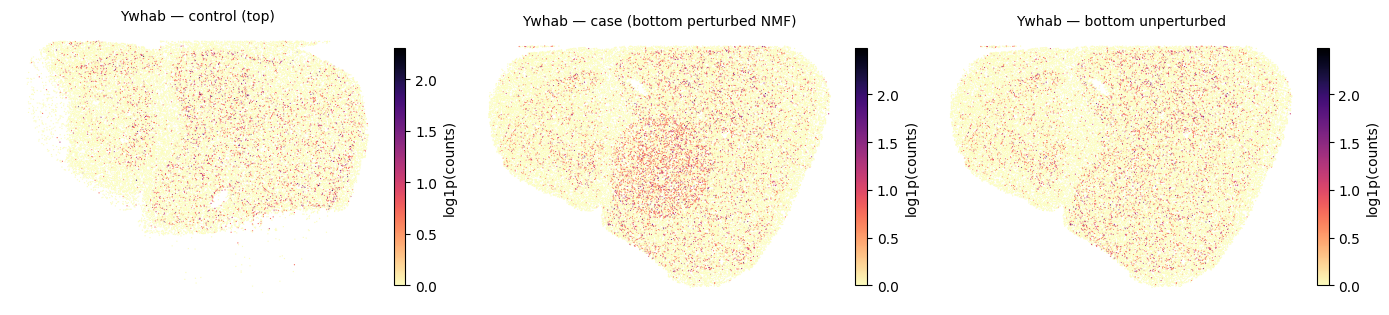

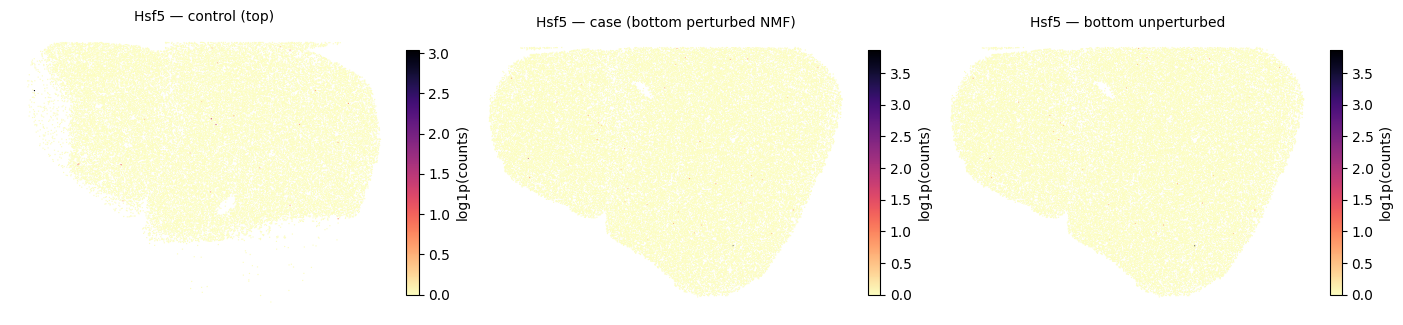

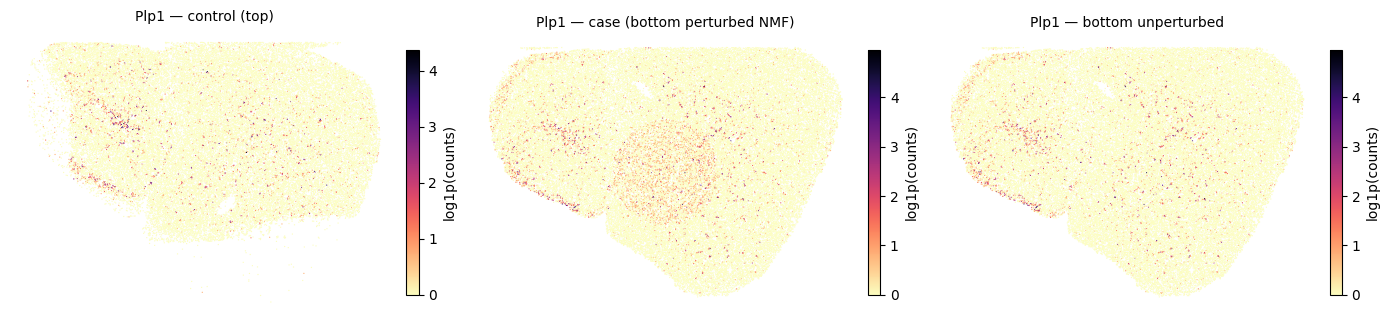

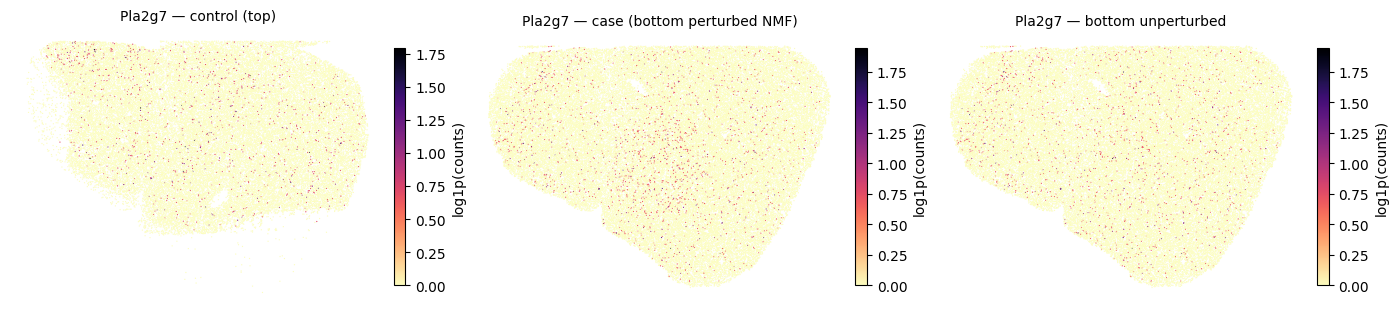

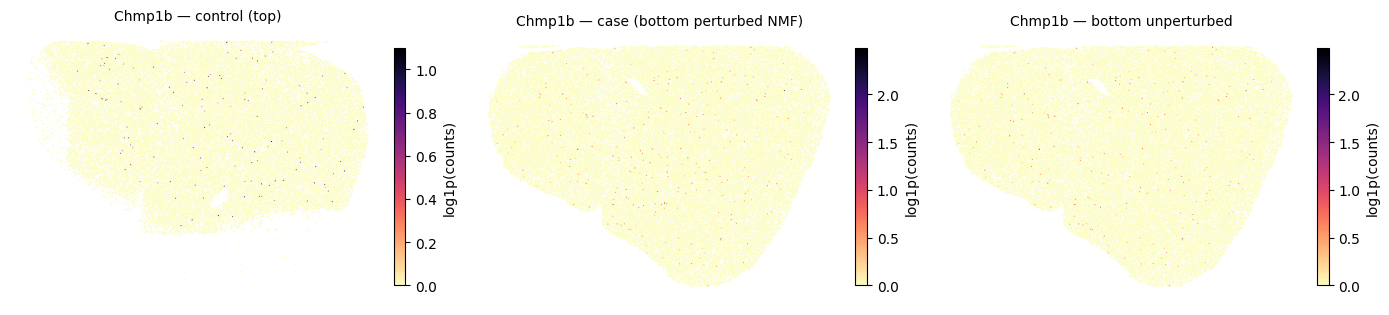

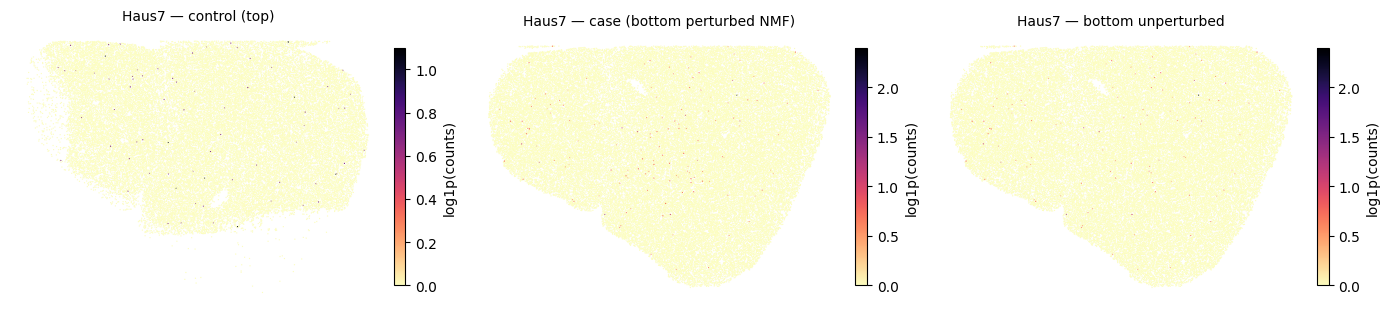

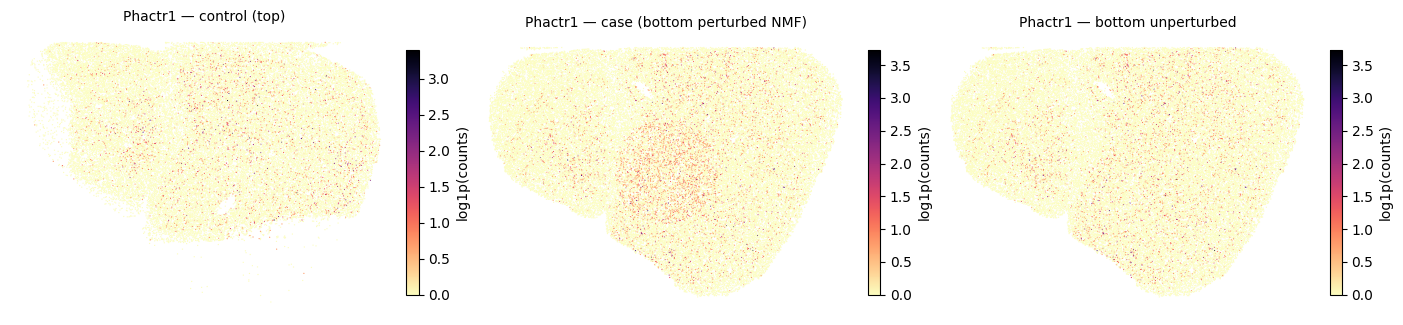

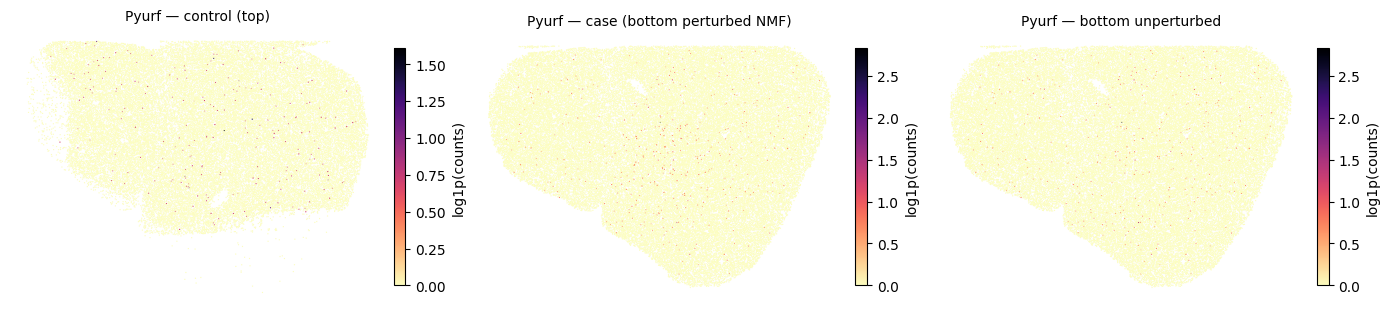

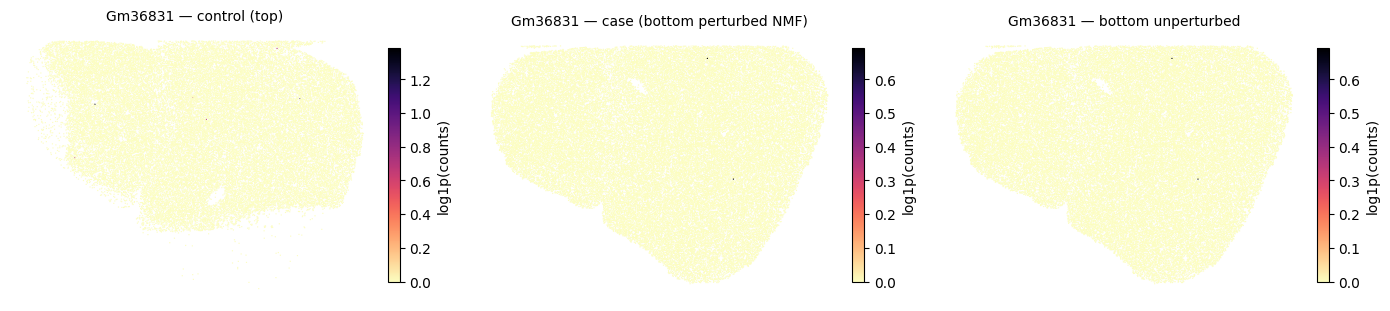

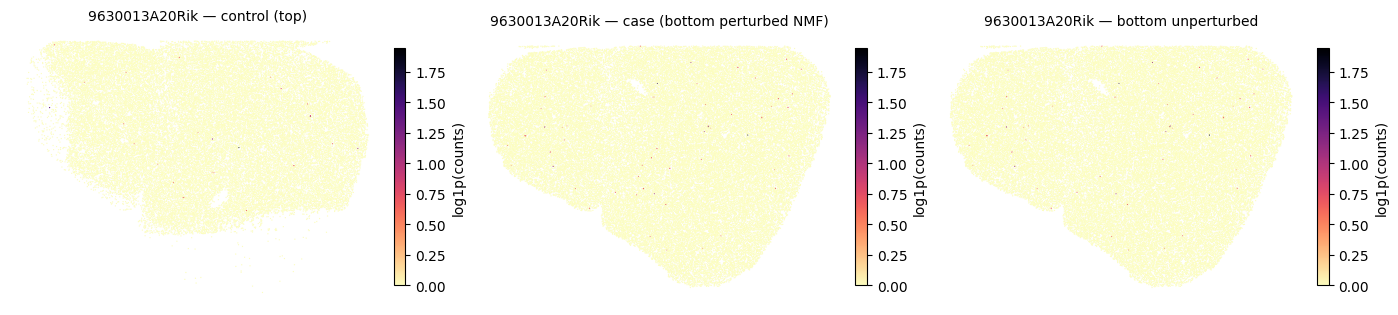

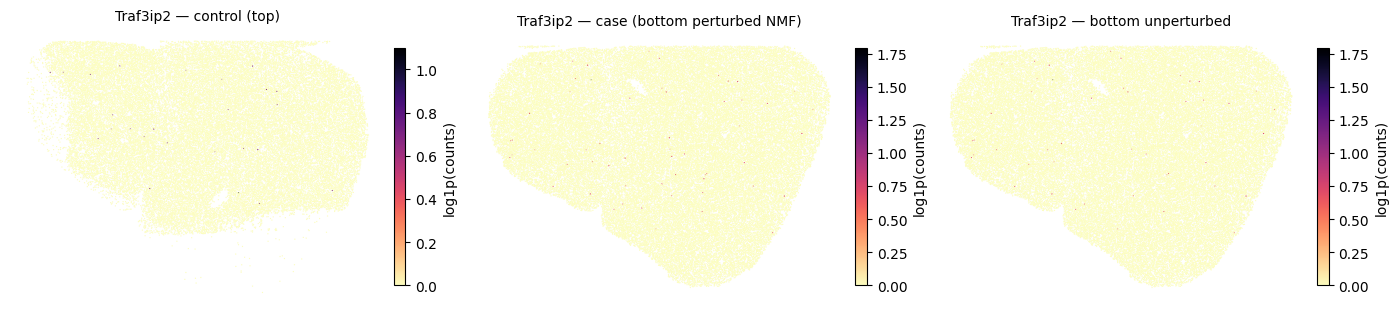

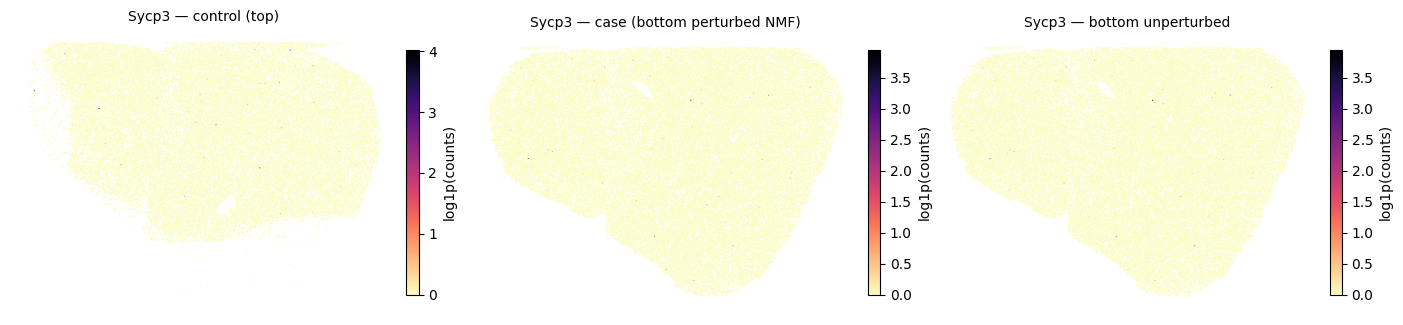

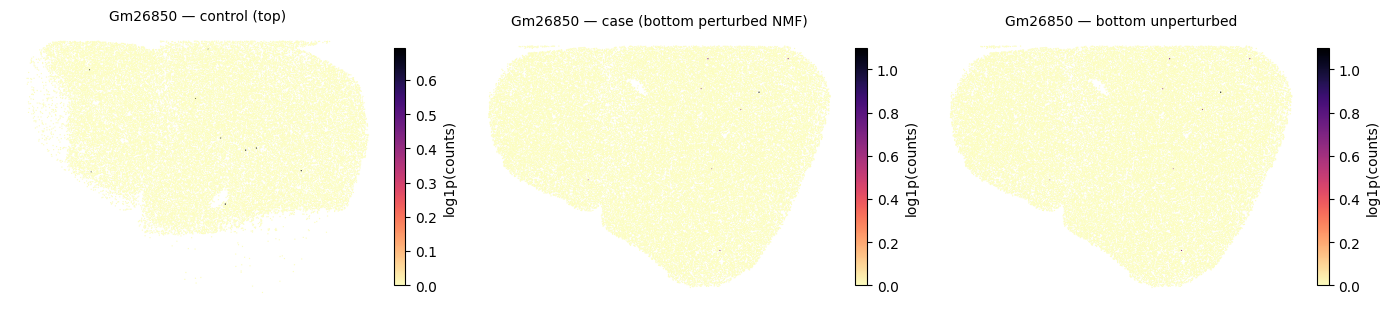

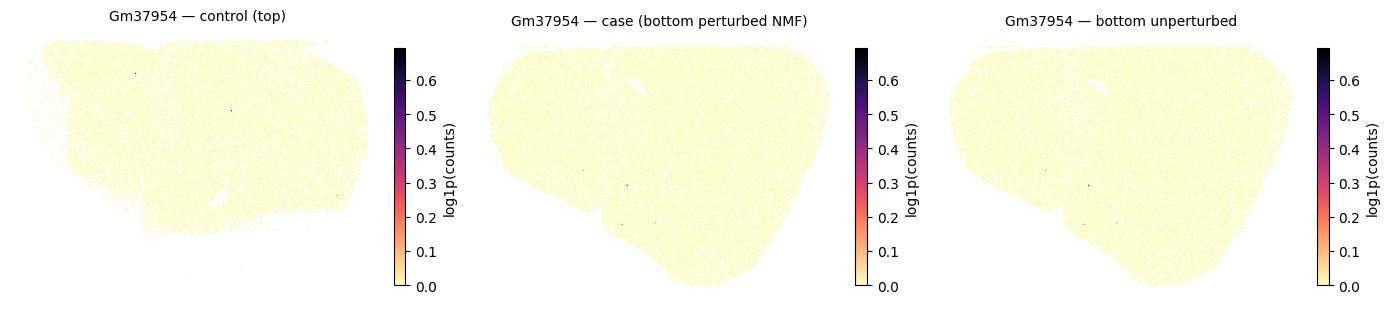

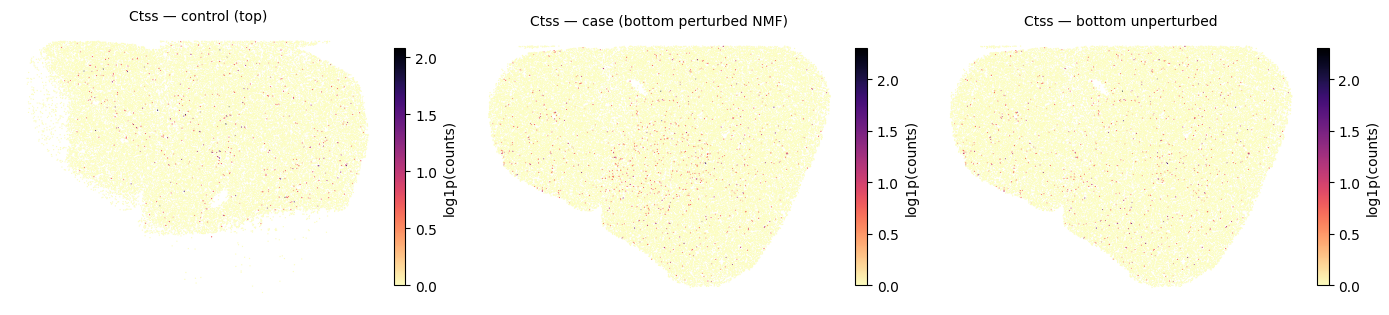

In [178]:
ROOT = Path('/lustre/scratch126/gengen/teams_v2/marks/dp31/SpatialPeeler')
DATA_DIR_OUT = ROOT / 'benchmark' / 'generated_benchmark_data'
adata06_top  = ad.read_h5ad(DATA_DIR_OUT / 'adata06_top.h5ad')
adata06_case = ad.read_h5ad(DATA_DIR_OUT / 'adata06_bot_case_nmfGenes.h5ad')
adata06_bot  = ad.read_h5ad(DATA_DIR_OUT / 'adata06_bot.h5ad')

genes_to_plot = nmf_genes_present[:20]

for gene in genes_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    for ax, adata, label in zip(axes,
                                 [adata06_top, adata06_case, adata06_bot],
                                 ['control (top)', 'case (bottom perturbed NMF)', 'bottom unperturbed']):
        feat_to_idx = dict(zip(adata.var['features'], adata.var_names))
        if gene not in feat_to_idx:
            ax.axis('off'); ax.set_title(f'{gene} not found', fontsize=9); continue
        expr = adata[:, feat_to_idx[gene]].X
        if hasattr(expr, 'toarray'):
            expr = expr.toarray().flatten()
        else:
            expr = np.asarray(expr).flatten()
        expr = np.log1p(expr)

        x_c = adata.obs['Raw_Slideseq_X'].values.astype(float)
        y_c = adata.obs['Raw_Slideseq_Y'].values.astype(float)

        sc_ = ax.scatter(x_c, y_c, c=expr, s=0.8, cmap='magma_r',
                         linewidths=0, edgecolors='none', rasterized=True)
        plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.02, label='log1p(counts)')
        ax.set_aspect('equal', 'box'); ax.axis('off')
        ax.set_title(f'{gene} — {label}', fontsize=10)

    plt.tight_layout()
    plt.show()